<>:77: SyntaxWarning: invalid escape sequence '\$'
<>:129: SyntaxWarning: invalid escape sequence '\$'
<>:77: SyntaxWarning: invalid escape sequence '\$'
<>:129: SyntaxWarning: invalid escape sequence '\$'
C:\Users\q8x7u\AppData\Local\Temp\ipykernel_7064\2166686084.py:77: SyntaxWarning: invalid escape sequence '\$'
  tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"",regex=True)
C:\Users\q8x7u\AppData\Local\Temp\ipykernel_7064\2166686084.py:129: SyntaxWarning: invalid escape sequence '\$'
  gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(',|\$',"",regex=True)

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\q8x7u\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
local HTML file load successfully.
         Date Revenue
0  2022-09-30   21454
1  2022-06-30   16934
2  2022-03-31   18756
3  2021-12-31   17719
4  2021-09-30   13757
Local HTML file (stock.html) loaded successfully.
         Date Revenue
0  2020-04-30    1021
1  2020-01-31    2194
2  2019-10-31    1439
3  2019-07-31    1286
4  2019-04-30    1548


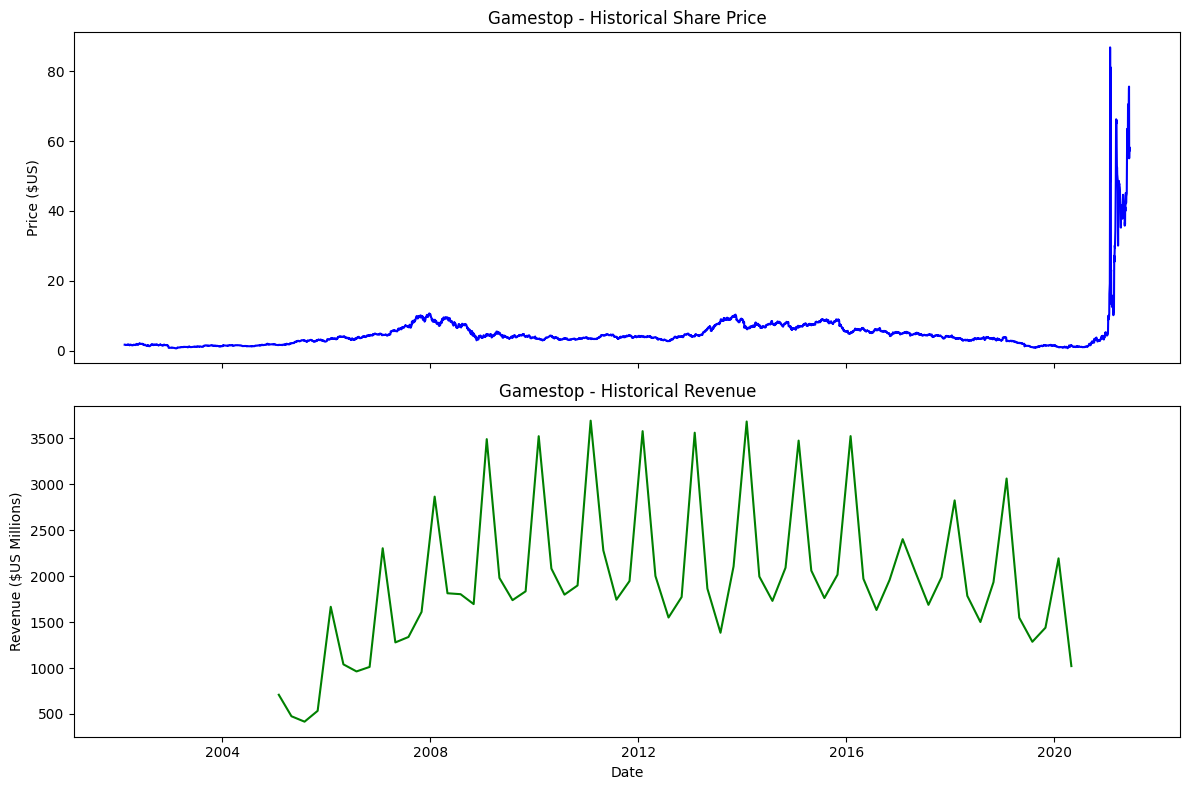

In [ ]:
# ----------------------------------
# 1. Import Libraries and Setup
# ----------------------------------

import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
# ----------------------------------
# 2. Define Graph Function
# ----------------------------------

def make_graph(stock_data, revenue_data, stock_name):
    # Convert Date columns to datetime
    stock_data['Date'] = pd.to_datetime(stock_data['Date'])
    revenue_data['Date'] = pd.to_datetime(revenue_data['Date'])

    # Filter dates
    stock_data_specific = stock_data[stock_data['Date'] <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data['Date'] <= '2021-04-30']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price plot
    axes[0].plot(
        stock_data_specific['Date'],
        stock_data_specific['Close'].astype(float),
        label="Share Price"
    )
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock_name} - Historical Share Price")
    axes[0].legend()

    # Revenue plot
    axes[1].plot(
        revenue_data_specific['Date'],
        revenue_data_specific['Revenue'].astype(float),
        label="Revenue"
    )
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock_name} - Historical Revenue")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
# ----------------------------------
# 3. Tesla Stock Price Data
# ----------------------------------

tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)

tesla_data.head()
# ----------------------------------
# 4. Tesla Revenue Data (Web Scraping - Local HTML)
# ----------------------------------

with open('revenue.html', 'r', encoding='utf-8') as f:
    html_data = f.read()

soup = BeautifulSoup(html_data, 'html.parser')

tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

tables = soup.find_all("table")
for table in tables:
    if "Tesla Quarterly Revenue" in str(table):
        tesla_table = table
        break

for row in tesla_table.find("tbody").find_all("tr"):
    col = row.find_all("td")
    if col:
        date = col[0].text
        revenue = col[1].text.replace("$", "").replace(",", "")
        tesla_revenue = pd.concat(
            [tesla_revenue, pd.DataFrame({"Date": [date], "Revenue": [revenue]})],
            ignore_index=True
        )

# Clean data
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]
tesla_revenue['Revenue'] = tesla_revenue['Revenue'].astype(float)
tesla_revenue['Date'] = pd.to_datetime(tesla_revenue['Date'])
tesla_revenue.sort_values('Date', inplace=True)

tesla_revenue.head()
# ----------------------------------
# 5. GameStop Stock Price Data
# ----------------------------------

gamestop = yf.Ticker("GME")
gme_data = gamestop.history(period="max")
gme_data.reset_index(inplace=True)

gme_data.head()
# ----------------------------------
# 6. GameStop Revenue Data (Web Scraping - Local HTML)
# ----------------------------------

with open('stock.html', 'r', encoding='utf-8') as f:
    html_data_2 = f.read()

gme_soup = BeautifulSoup(html_data_2, 'html.parser')

gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

tables = gme_soup.find_all("table")
for table in tables:
    if "GameStop Quarterly Revenue" in str(table):
        gme_table = table
        break

for row in gme_table.find("tbody").find_all("tr"):
    col = row.find_all("td")
    if col:
        date = col[0].text
        revenue = col[1].text.replace("$", "").replace(",", "")
        gme_revenue = pd.concat(
            [gme_revenue, pd.DataFrame({"Date": [date], "Revenue": [revenue]})],
            ignore_index=True
        )

# Clean data
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]
gme_revenue['Revenue'] = gme_revenue['Revenue'].astype(float)
gme_revenue['Date'] = pd.to_datetime(gme_revenue['Date'])
gme_revenue.sort_values('Date', inplace=True)

gme_revenue.head()
# ----------------------------------
# 7. Data Visualization
# ----------------------------------

make_graph(tesla_data, tesla_revenue, "Tesla")
make_graph(gme_data, gme_revenue, "GameStop")
